In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression

from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)


In [2]:
df = pd.read_csv("<your path for final dataset>", sep=None, engine="python")
df.shape

(608304, 45)

In [3]:
y = df["is_alarm"]

X = df.drop(["is_alarm"], axis=1)
X = X.select_dtypes(include=[np.number])

#remove NAN

data = pd.concat([X, y], axis=1)

data = data.dropna()

X = data.drop("is_alarm", axis=1)
y = data["is_alarm"]

feature_names = X.columns.tolist()

In [4]:
data.shape

(21625, 31)

In [5]:
len(feature_names)

30

FEATURE SEPARATION ANALYSIS

In [6]:
def analyze_feature_separation(df, target_col, feature_cols):

    print("\nFeature separation analysis:\n")

    for feature in feature_cols:

        try:

            mean_1 = df[df[target_col] == 1][feature].mean()
            mean_0 = df[df[target_col] == 0][feature].mean()

            diff = mean_1 - mean_0

            print(f"Фіча: {feature}")
            print(f"1: {mean_1:.4f}")
            print(f"0: {mean_0:.4f}")
            print(f"{diff:.4f}\n")

        except:
            continue


analyze_feature_separation(df, "is_alarm", feature_names)


Feature separation analysis:

Фіча: day_datetimeEpoch
1: 1691174638.8672
0: 1685572350.7732
5602288.0940

Фіча: day_tempmax
1: 15.2145
0: 14.6961
0.5184

Фіча: day_tempmin
1: 6.0204
0: 5.6053
0.4151

Фіча: day_temp
1: 10.5918
0: 10.1240
0.4677

Фіча: day_dew
1: 5.2046
0: 4.6976
0.5070

Фіча: day_humidity
1: 73.1573
0: 72.7149
0.4424

Фіча: day_precip
1: 2.0119
0: 2.1777
-0.1658

Фіча: day_precipcover
1: 4.8470
0: 4.5563
0.2907

Фіча: day_solarradiation
1: 142.4089
0: 143.3023
-0.8933

Фіча: day_solarenergy
1: 12.2780
0: 12.3252
-0.0472
Фіча: day_uvindex
1: 4.8044
0: 4.8381
-0.0336

Фіча: day_moonphase
1: 0.4896
0: 0.4910
-0.0014

Фіча: hour_datetimeEpoch
1: 1691216056.5233
0: 1685612955.1546
5603101.3687

Фіча: hour_temp
1: 10.5878
0: 10.1855
0.4023

Фіча: hour_humidity
1: 73.1578
0: 72.6893
0.4685

Фіча: hour_dew
1: 5.2028
0: 4.7197
0.4832

Фіча: hour_precip
1: 0.0847
0: 0.0598
0.0249

Фіча: hour_precipprob
1: 4.8639
0: 3.9304
0.9335

Фіча: hour_snow
1: 0.0048
0: 0.0039
0.0009

Фіча:

Scaling

In [7]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


tscv = TimeSeriesSplit(n_splits=5)

TRAINING 

In [8]:
def train_linear_regression(X_train, y_train, X_test, y_test):

    model = LinearRegression()

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return model, rmse, mae, r2


def train_logistic_regression(X_train, y_train, X_test, y_test):

    model = LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    )

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    return model, accuracy, precision, recall, f1

CROSS VALIDATION

In [9]:
lr_results = []
log_results = []
splits = []

for train_index, test_index in tscv.split(X_scaled):

    X_train, X_test = X_scaled[train_index], X_scaled[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    splits.append((train_index, test_index))

    # Linear Regression
    lr_model, rmse, mae, r2 = train_linear_regression(
        X_train, y_train, X_test, y_test
    )

    lr_results.append((rmse, mae, r2, lr_model))

    # Logistic Regression
    log_model, acc, prec, rec, f1 = train_logistic_regression(
        X_train, y_train, X_test, y_test
    )

    log_results.append((acc, prec, rec, f1, log_model))

In [10]:
avg_rmse = np.mean([r[0] for r in lr_results])
avg_mae = np.mean([r[1] for r in lr_results])
avg_r2 = np.mean([r[2] for r in lr_results])

avg_acc = np.mean([r[0] for r in log_results])
avg_prec = np.mean([r[1] for r in log_results])
avg_rec = np.mean([r[2] for r in log_results])
avg_f1 = np.mean([r[3] for r in log_results])

In [11]:
print("\nLinear Regression Results")
print("RMSE:", avg_rmse)
print("MAE:", avg_mae)
print("R2:", avg_r2)

print("\nLogistic Regression Results")
print("Accuracy:", avg_acc)
print("Precision:", avg_prec)
print("Recall:", avg_rec)
print("F1:", avg_f1)


Linear Regression Results
RMSE: 0.17603271725846023
MAE: 0.07402190118214037
R2: -0.508891040053203

Logistic Regression Results
Accuracy: 0.8395671476137625
Precision: 0.9776894047309665
Recall: 0.8545279938770962
F1: 0.8991071784061913


HYPERPARAMETER SEARCH

In [12]:

param_grid = {
    "C":[0.01,0.1,1,10],
    "solver":["lbfgs","liblinear"],
    "max_iter":[500,1000]
}

last_train, last_test = splits[-1]

X_train = X_scaled[last_train]
X_test = X_scaled[last_test]

y_train = y.iloc[last_train]
y_test = y.iloc[last_test]

best_score = 0
best_params = None

for C in param_grid["C"]:
    for solver in param_grid["solver"]:
        for max_iter in param_grid["max_iter"]:

            model = LogisticRegression(
                C=C,
                solver=solver,
                max_iter=max_iter,
                class_weight="balanced"
            )

            model.fit(X_train, y_train)

            score = model.score(X_test, y_test)

            if score > best_score:

                best_score = score
                best_params = {
                    "C":C,
                    "solver":solver,
                    "max_iter":max_iter
                }

print("\nBest parameters:", best_params)
print("Best accuracy:", best_score)


Best parameters: {'C': 10, 'solver': 'lbfgs', 'max_iter': 500}
Best accuracy: 0.5188679245283019


In [13]:
final_model = LogisticRegression(
    **best_params,
    class_weight="balanced"
)

final_model.fit(X_train, y_train)

y_pred = final_model.predict(X_test)

CONFUSION MATRIX


Confusion Matrix
[[  58   51]
 [1683 1812]]

Classification Report
              precision    recall  f1-score   support

         0.0       0.03      0.53      0.06       109
         1.0       0.97      0.52      0.68      3495

    accuracy                           0.52      3604
   macro avg       0.50      0.53      0.37      3604
weighted avg       0.94      0.52      0.66      3604


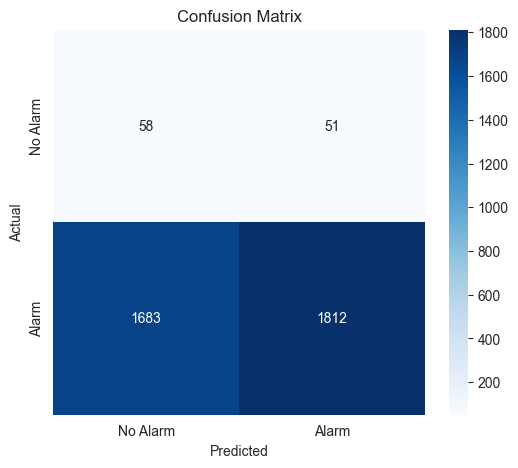

In [14]:
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix")
print(cm)

print("\nClassification Report")
print(classification_report(y_test, y_pred))

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Alarm","Alarm"],
    yticklabels=["No Alarm","Alarm"]
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()


FEATURE IMPORTANCE

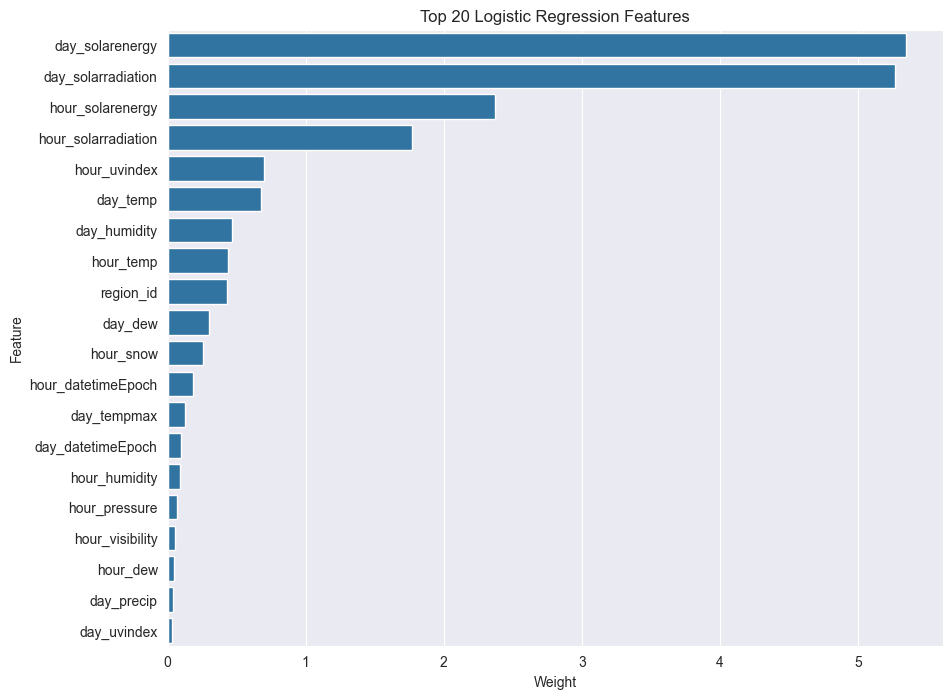

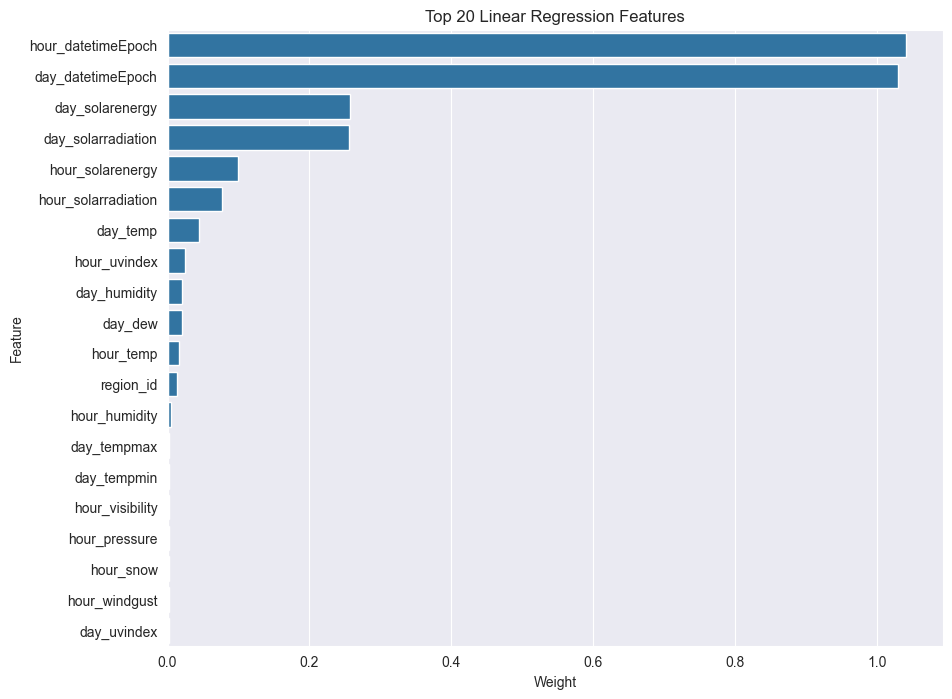

In [15]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Weight": np.abs(final_model.coef_[0])
})

importance = importance.sort_values(by="Weight", ascending=False)

top20 = importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=top20,
    x="Weight",
    y="Feature"
)

plt.title("Top 20 Logistic Regression Features")

plt.show()

# Linear regression importance

lr_model = lr_results[-1][3]

lr_importance = pd.DataFrame({
    "Feature": feature_names,
    "Weight": np.abs(lr_model.coef_)
})

lr_importance = lr_importance.sort_values(by="Weight", ascending=False)

lr_top20 = lr_importance.head(20)

plt.figure(figsize=(10,8))

sns.barplot(
    data=lr_top20,
    x="Weight",
    y="Feature"
)

plt.title("Top 20 Linear Regression Features")

plt.show()